# Final XGBoost Production Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)


In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
TARGET = "late_delivery_flag"
MODEL_NAME = "XGBoost"


## Load Processed Dataset

In [3]:
DATA_PATH = Path("../data/processed/final_processed_datasets")
fact_orders = pd.read_csv(DATA_PATH / "fact_orders_fe.csv")
fact_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_after_carrier_flag,late_delivery_flag,delivery_before_carrier_flag,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_count,payment_type,max_installments,review_score,review_comment_title,review_comment_message,purchase_year,purchase_month,purchase_month_name,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,approval_time_hours,shipping_time_days,delivery_time_days,total_order_cycle_days,estimated_delivery_days,delivery_delay_days,avg_payment_per_installment,multiple_payment_methods,high_rating,low_rating,is_delivered,is_cancelled,is_in_progress
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,False,False,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,3.00,"credit_card, voucher",1.00,4.00,NaN,"Não testei o produto ainda, mas ele veio corre...",2017,10,October,4,2,Monday,10,0.18,2.00,6.00,8.00,15,-8.00,38.71,True,True,False,True,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,False,False,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.00,boleto,1.00,4.00,Muito boa a loja,Muito bom o produto.,2018,7,July,3,24,Tuesday,20,30.71,0.00,12.00,13.00,19,-6.00,141.46,False,True,False,True,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,False,False,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,1.00,credit_card,3.00,5.00,NaN,NaN,2018,8,August,3,8,Wednesday,8,0.28,0.00,9.00,9.00,26,-18.00,59.71,False,True,False,True,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,False,False,False,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.00,credit_card,1.00,5.00,NaN,O produto foi exatamente o que eu esperava e e...,2017,11,November,4,18,Saturday,19,0.30,3.00,9.00,13.00,26,-13.00,72.20,False,True,False,True,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,False,False,False,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.00,credit_card,1.00,5.00,NaN,NaN,2018,2,February,1,13,Tuesday,21,1.03,0.00,1.00,2.00,12,-10.00,28.62,False,True,False,True,False,False


## Feature Selection

In [4]:
DROP_COLUMNS = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "review_score",
    "review_comment_title",
    "review_comment_message",
    "approval_time_hours",
    "shipping_time_days",
    "delivery_time_days",
    "total_order_cycle_days",
    "delivery_delay_days",
    "order_status",
]

model_df = fact_orders.drop(columns=DROP_COLUMNS).copy()

feature_columns = [
    "customer_zip_code_prefix",
    "customer_city",
    "customer_state",
    "total_payment",
    "payment_count",
    "payment_type",
    "max_installments",
    "avg_payment_per_installment",
    "multiple_payment_methods",
    "purchase_year",
    "purchase_month",
    "purchase_month_name",
    "purchase_quarter",
    "purchase_day",
    "purchase_weekday",
    "purchase_hour",
    "estimated_delivery_days",
]

X = model_df[feature_columns].copy()
y = model_df[TARGET].astype(int)

forbidden_features = [
    "high_rating",
    "low_rating",
    "review_score",
    "review_comment_title",
    "review_comment_message",
    "is_delivered",
    "is_cancelled",
    "is_in_progress",
    "approval_after_carrier_flag",
    "delivery_before_carrier_flag",
    "delivery_time_days",
    "delivery_delay_days",
    "shipping_time_days",
    "total_order_cycle_days",
    "order_delivered_customer_date",
    "order_delivered_carrier_date",
]

leaked = sorted(set(X.columns) & set(forbidden_features))
print("Leakage detected:", leaked)
assert len(leaked) == 0, f"LEAKAGE FOUND: {leaked}"
print("✅ Feature leakage check passed")


Leakage detected: []
✅ Feature leakage check passed


## Train-Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)


Training Shape : (79552, 17)
Testing Shape  : (19889, 17)


## Automatic Feature Detection

In [6]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
boolean_features = X.select_dtypes(include=["bool"]).columns.tolist()

print(f"Numeric Features    : {len(numeric_features)}")
print(f"Categorical Features: {len(categorical_features)}")
print(f"Boolean Features    : {len(boolean_features)}")


Numeric Features    : 11
Categorical Features: 5
Boolean Features    : 1


## Preprocessing Pipeline

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_pipeline_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_tree, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
        ("bool", "passthrough", boolean_features),
    ]
)


## XGBoost Pipeline

In [8]:
from xgboost import XGBClassifier

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")),
    ]
)


## Baseline Evaluation

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("Classification Report")
print(classification_report(y_test, y_pred))


Accuracy : 0.9236764040424356
Precision: 0.5959183673469388
Recall   : 0.09329073482428114
F1       : 0.16132596685082873
ROC AUC  : 0.7969235863090568
Confusion Matrix
[[18225    99]
 [ 1419   146]]
Classification Report
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     18324
           1       0.60      0.09      0.16      1565

    accuracy                           0.92     19889
   macro avg       0.76      0.54      0.56     19889
weighted avg       0.90      0.92      0.90     19889



## Threshold Optimization

In [10]:
threshold_results = []
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold),
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,Threshold,Precision,Recall,F1 Score
0,0.10,0.23,0.61,0.34
1,0.20,0.35,0.40,0.37
2,0.30,0.41,0.26,0.32
3,0.40,0.48,0.15,0.23
4,0.50,0.60,0.09,0.16
5,0.60,0.62,0.04,0.08
6,0.70,0.75,0.01,0.02
7,0.80,0.75,0.00,0.01
8,0.90,0.50,0.00,0.00


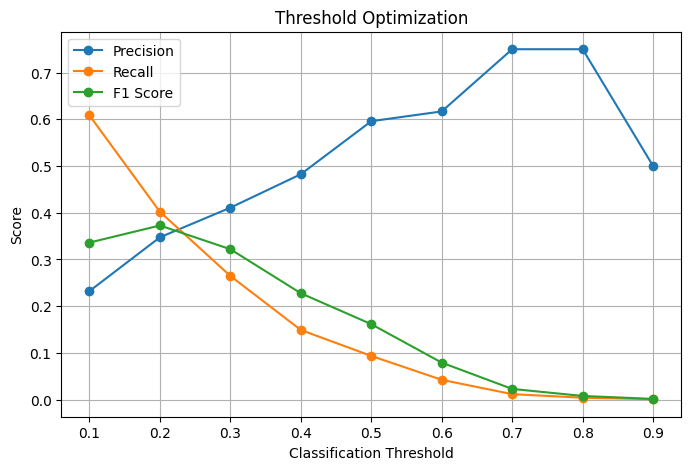

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1 Score"], marker="o", label="F1 Score")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()
plt.grid(True)
plt.show()


## Cross Validation

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)

print("CV F1 Mean :", cv_scores.mean())
print("CV F1 Std  :", cv_scores.std())


CV F1 Mean : 0.1339918466090318
CV F1 Std  : 0.010613848901388391


## RandomizedSearchCV

In [13]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [3, 5, 7, 10],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.6, 0.8, 1.0],
    "classifier__min_child_weight": [1, 3, 5],
}

xgb_random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
)

xgb_random_search.fit(X_train, y_train)

print("Best Parameters:", xgb_random_search.best_params_)
print("Best CV Score :", xgb_random_search.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


KeyboardInterrupt: 

## Final Evaluation

Accuracy : 0.9196038010960833
Precision: 0.46064814814814814
Recall   : 0.12715654952076677
F1       : 0.19929894842263396
ROC AUC  : 0.7833402378068044
Confusion Matrix
[[18091   233]
 [ 1366   199]]


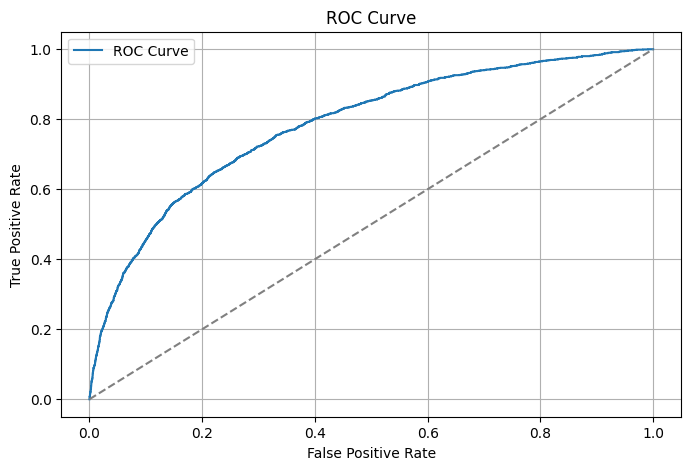

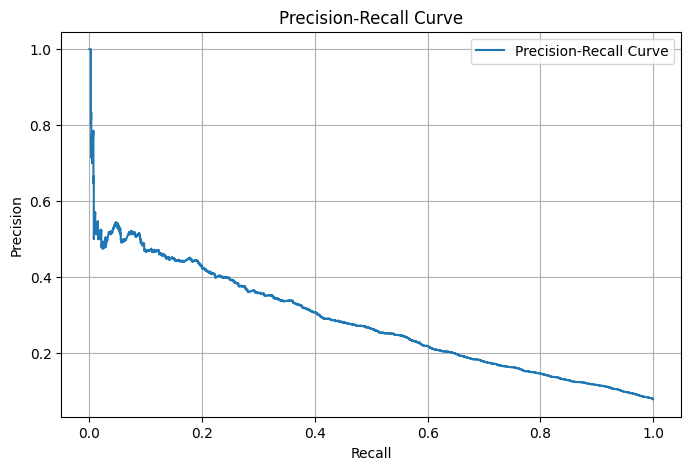

In [17]:
best_xgb = xgb_random_search.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import roc_curve, precision_recall_curve

plt.figure(figsize=(8, 5))
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()


## Feature Importance

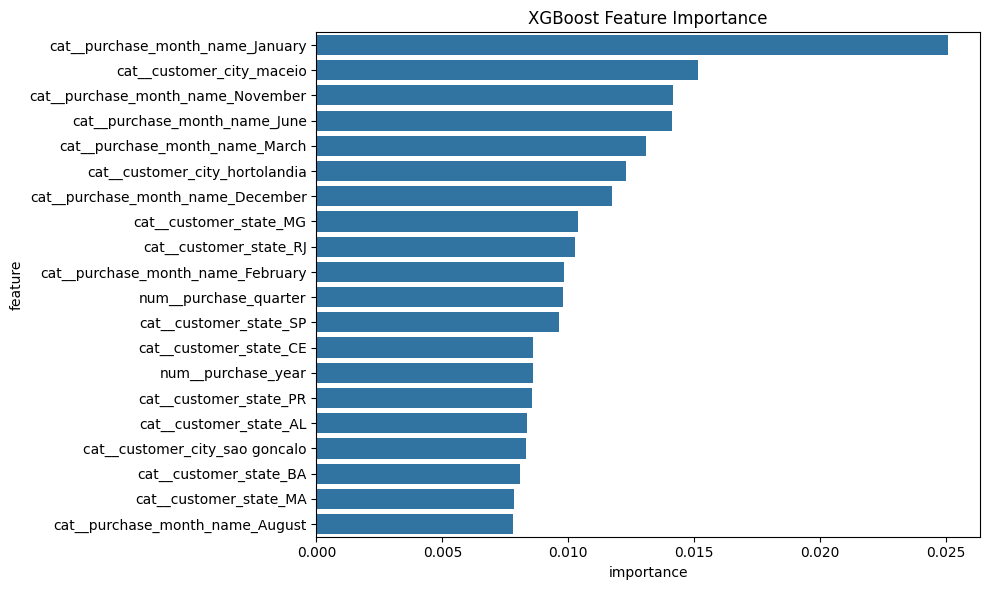

In [18]:
preprocessor = best_xgb.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

xgb_model = best_xgb.named_steps["classifier"]
importance = xgb_model.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance,
}).sort_values(by="importance", ascending=False)

importance_df

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature",
)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()


## SHAP Explainability

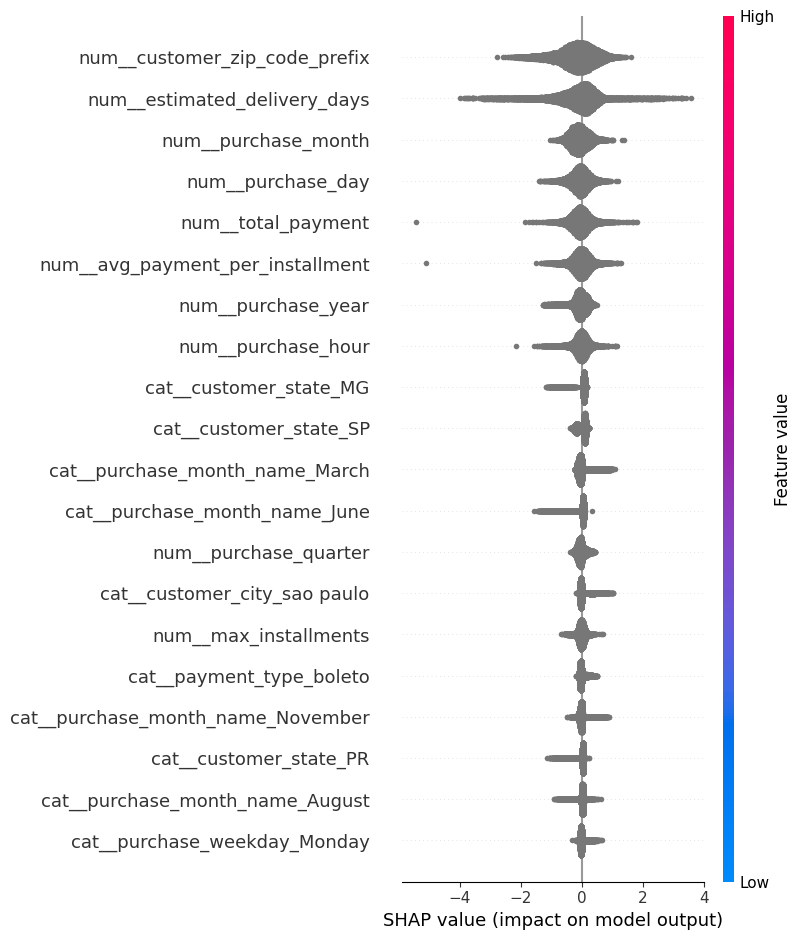

In [20]:
import shap

X_test_processed = preprocessor.transform(X_test)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
)


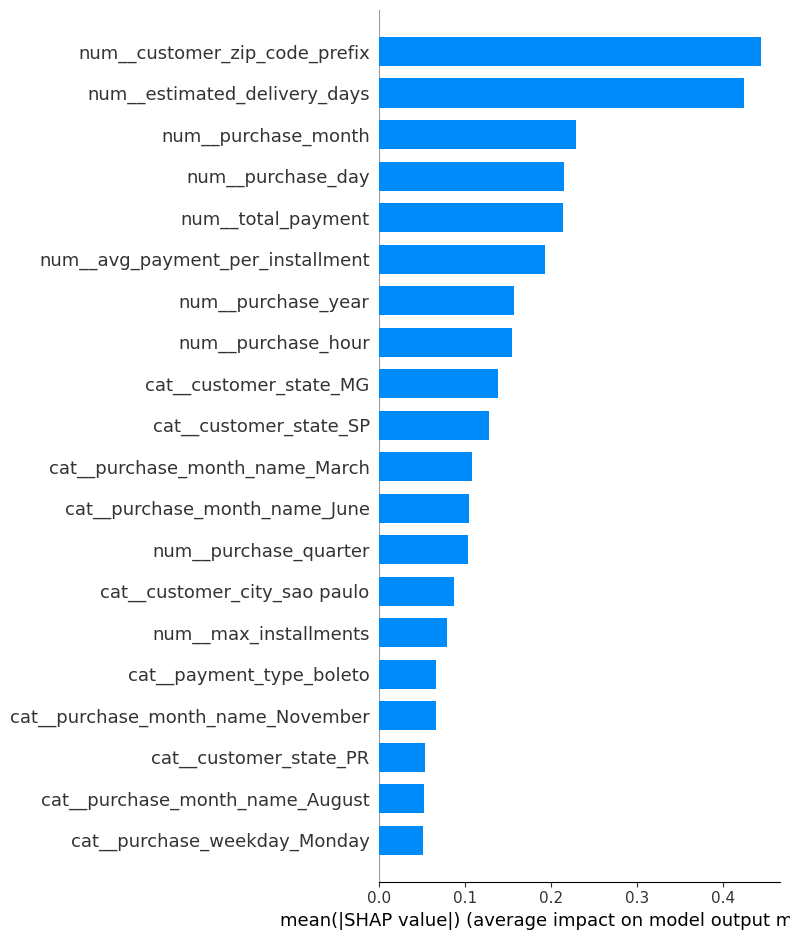

In [21]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar",
)

IndexError: index (2046) out of range

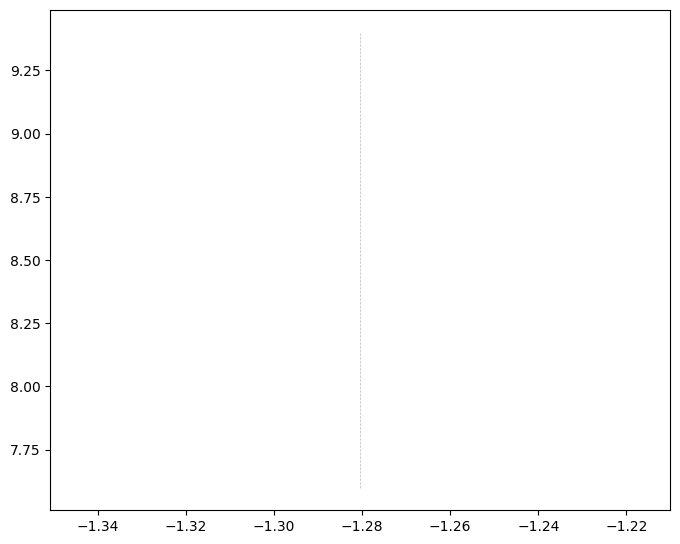

In [ ]:

shap.waterfall_plot(
    shap.Explanation(values=shap_values[0], base_values=explainer.expected_value, data=X_test_processed[0], feature_names=feature_names)
) 

## Save Model

In [23]:
import joblib

Path("models").mkdir(exist_ok=True)
model_path = Path("models/late_delivery_xgboost_pipeline.joblib")
joblib.dump(best_xgb, model_path)
print(f"Model saved to {model_path}")

loaded_model = joblib.load(model_path)
print(f"Loaded model type: {type(loaded_model)}")


Model saved to models\late_delivery_xgboost_pipeline.joblib
Loaded model type: <class 'sklearn.pipeline.Pipeline'>


## Notebook Summary

- Dataset: Processed Olist late delivery dataset with leakage features removed.
- Business Problem: Predict whether an order will be delivered late.
- Leakage Fix: Explicit allow-list used for feature selection; forbidden future/time-leakage features audited and blocked.
- Model: XGBoost with tree preprocessing pipeline.
- Threshold: Evaluated multiple thresholds for the positive class.
- Final Metrics: Accuracy, Precision, Recall, F1, ROC AUC reported on the test set.
- Best Parameters: Optimized with RandomizedSearchCV.
- Deployment Ready: Pipeline saved to `models/late_delivery_xgboost_pipeline.joblib`.
